In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Vgsales.xlsx to Vgsales.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_excel("Vgsales.xlsx")
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
# Remove rows where Global_Sales is 0 to avoid division errors
df = df[df['Global_Sales'] > 0].copy()

In [ ]:
# -----------------------------
# 2. Create regional ratios
# -----------------------------
df['NA_ratio'] = df['NA_Sales'] / df['Global_Sales']
df['EU_ratio'] = df['EU_Sales'] / df['Global_Sales']
df['JP_ratio'] = df['JP_Sales'] / df['Global_Sales']

# -----------------------------
# 4. Standardize features
# -----------------------------

features = df[['NA_ratio', 'EU_ratio', 'JP_ratio']].copy()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


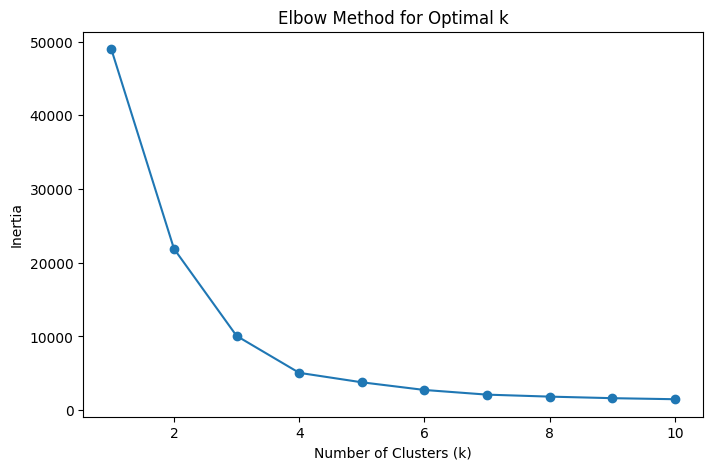

In [ ]:
# -----------------------------
# 5. Elbow method
# -----------------------------
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [ ]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

In [ ]:
cluster_summary = df.groupby('Cluster')[['NA_ratio', 'EU_ratio', 'JP_ratio']].mean()
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         NA_ratio  EU_ratio  JP_ratio
Cluster                              
0        0.773741  0.128047  0.028094
1        0.023948  0.012408  0.952683
2        0.348902  0.503529  0.029303


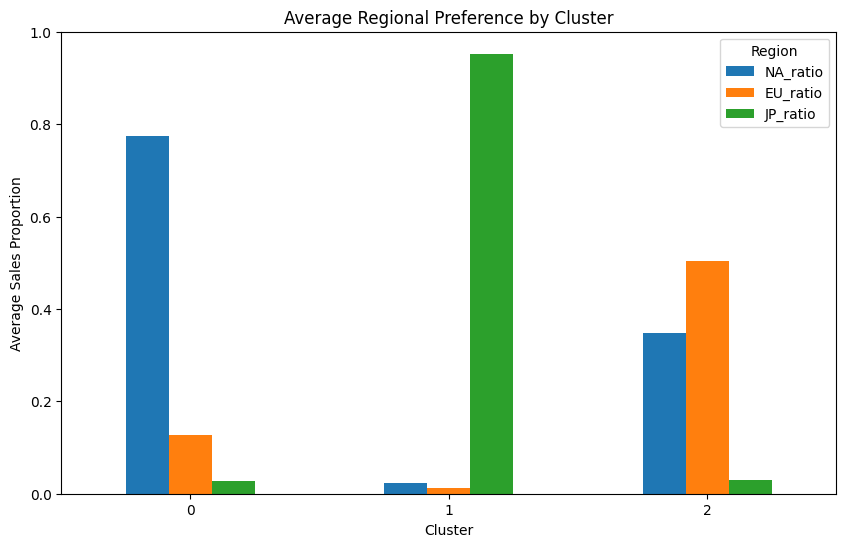

In [ ]:
# -----------------------------
# 8. Bar chart of cluster means
# -----------------------------
cluster_summary.plot(kind='bar', figsize=(10, 6))
plt.title('Average Regional Preference by Cluster')
plt.ylabel('Average Sales Proportion')
plt.xticks(rotation=0)
plt.legend(title='Region')
plt.show()

In [ ]:
# -----------------------------
# 9. Genre distribution by cluster
# -----------------------------
genre_cluster = df.groupby(['Cluster', 'Genre']).size().unstack(fill_value=0)
print("\nGenre Distribution by Cluster:")
print(genre_cluster)


Genre Distribution by Cluster:
Genre    Action  Adventure  Fighting  Misc  Platform  Puzzle  Racing  \
Cluster                                                                
0          1374        317       329   834       507     329     578   
1           619        665       281   427        81      93      64   
2          1259        294       226   449       288     149     584   

Genre    Role-Playing  Shooter  Simulation  Sports  Strategy  
Cluster                                                       
0                 404      588         382    1129       176  
1                 692       98         180     377       221  
2                 373      596         288     798       274  


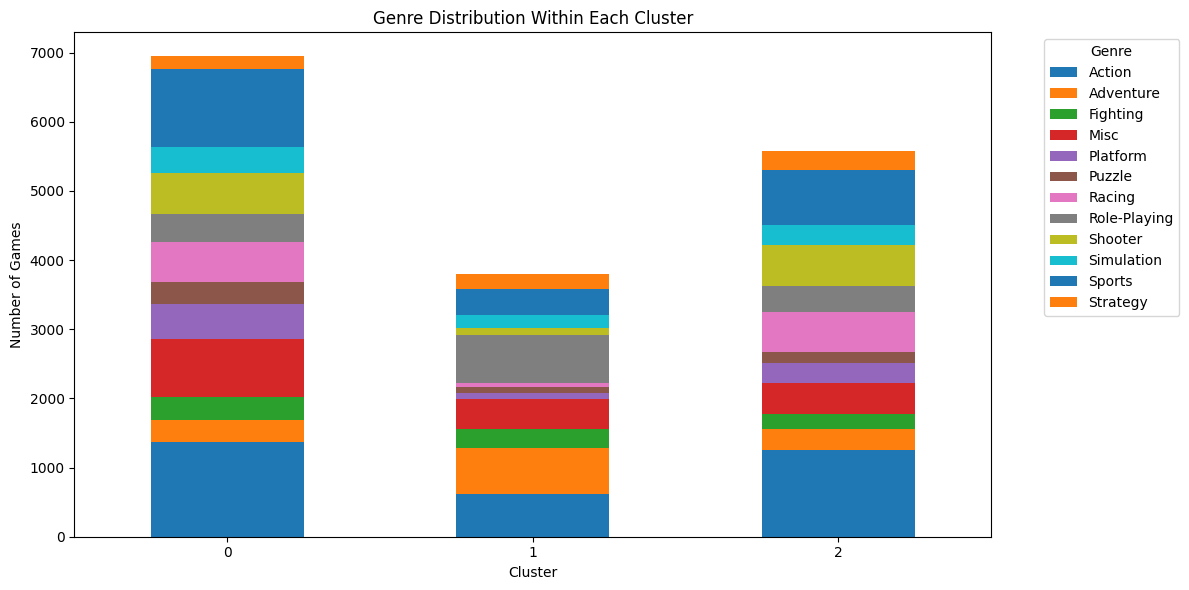

In [ ]:
# -----------------------------
# 10. Stacked bar chart of genres
# -----------------------------
genre_cluster.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Genre Distribution Within Each Cluster')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



Cluster Sizes:
Cluster
0    6947
1    3798
2    5578
Name: count, dtype: int64


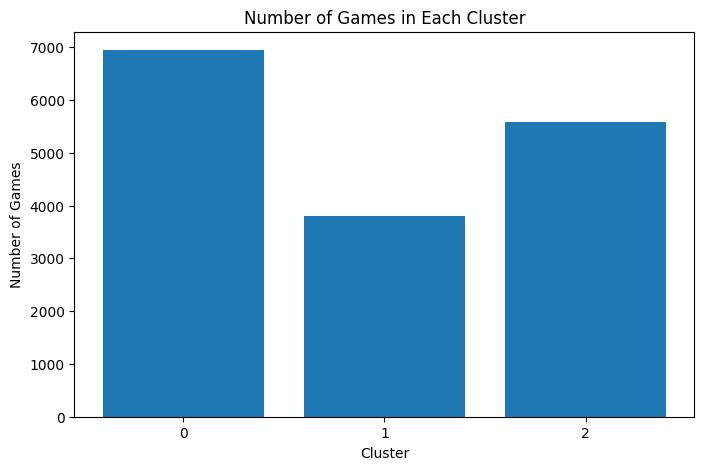

In [ ]:
# -----------------------------
# 11. Cluster sizes
# -----------------------------
cluster_sizes = df['Cluster'].value_counts().sort_index()
print("\nCluster Sizes:")
print(cluster_sizes)

plt.figure(figsize=(8, 5))
plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Games')
plt.title('Number of Games in Each Cluster')
plt.show()

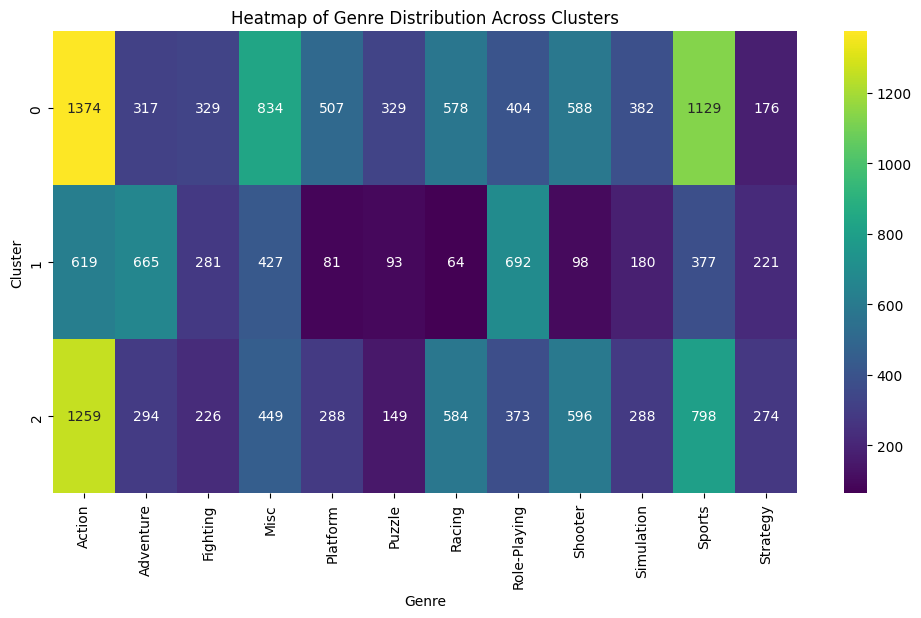

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    genre_cluster,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.title('Heatmap of Genre Distribution Across Clusters')
plt.xlabel('Genre')
plt.ylabel('Cluster')

plt.show()